In [82]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [83]:
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader

In [84]:
device = "cuda" if torch.cuda.is_available() else "cpu"

img_size = (128, 128)
num_classes = 3

transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                        (0.229, 0.224, 0.225))
])

def target_transforms(target):
    img = transforms.Resize(img_size)(target)
    img = transforms.functional.pil_to_tensor(img).squeeze_()
    img = img-1

    img = img.to(torch.long)
    return img

def de_normalize(img,
                    mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)):
    result = img * std + mean
    result = np.clip(result, 0.0, 1.0)

    return result

In [85]:
train_set = OxfordIIITPet(root='./unet', split='trainval', target_types="segmentation",transform=transform, target_transform=target_transforms, download=True)
test_set = OxfordIIITPet(root='./unet', split='test', target_types="segmentation", transform=transform, target_transform=target_transforms, download=True)

In [86]:
batch_size = 32
num_workers = 2

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [87]:
class ConvBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()

    self.conv_block = nn.Sequential(
      nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(num_features=out_channels),
      nn.ReLU(inplace=True),
      nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding=1, bias=False),
      nn.BatchNorm2d(num_features=out_channels),
      nn.ReLU(inplace=True),
    )

  def forward(self, x):
    return self.conv_block(x)

In [88]:
class Encoder(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.MaxPool2d(2),
        ConvBlock(in_channels, out_channels)
    )

  def forward(self, x):
    return self.encoder(x)

In [89]:
class Decoder(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()

    self.conv_trans = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
    self.conv_block = ConvBlock(in_channels, out_channels)

  def forward(self, x1, x2):
      x1 = self.conv_trans(x1)
      x = torch.cat([x2, x1], dim=1)
      x = self.conv_block(x)
      return x

In [90]:
class Unet(nn.Module):
  def __init__(self, n_channels, n_classes):
    super().__init__()

    self.in_conv = ConvBlock(n_channels, 64)

    self.enc_1 = Encoder(64, 128)
    self.enc_2 = Encoder(128, 256)
    self.enc_3 = Encoder(256, 512)
    self.enc_4 = Encoder(512, 1024)


    self.dec_1 = Decoder(1024, 512)
    self.dec_2 = Decoder(512, 256)
    self.dec_3 = Decoder(256, 128)
    self.dec_4 = Decoder(128, 64)

    self.conv = nn.Conv2d(64, n_classes, kernel_size=1)
  def forward(self, x):
    x1 = self.in_conv(x)

    enc1 = self.enc_1(x1)
    enc2 = self.enc_2(enc1)
    enc3 = self.enc_3(enc2)
    enc4 = self.enc_4(enc3)

    x = self.dec_1(enc4, enc3)
    x = self.dec_2(x, enc2)
    x = self.dec_3(x, enc1)
    x = self.dec_4(x, x1)

    x = self.conv(x)
    return x


In [95]:
def evaluate(test_loader, model):
  critation = nn.CrossEntropyLoss()
  test_loss = 0.0
  model.eval()

  with torch.no_grad():
    for (image, label) in test_loader:
      image = image.to(device)
      label = label.to(device)

      logit = model(image)
      loss = critation(logit, label)

      test_loss += loss.item()

    test_loss /= len(test_loader)
    return test_loss

In [92]:
model = Unet(n_channels=3, n_classes=3).to(device)
epochs = 30
lr = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [93]:
@torch.inference_mode()
def display_prediction(model, image, target):
    model.eval()
    img = image[None,...].to(device)
    output = model(img)
    pred = torch.argmax(output, axis=1)

    plt.figure(figsize=(10, 5))

    plt.subplot(1,3,1)
    plt.axis('off')
    plt.title("Input Image")
    plt.imshow(de_normalize(image.numpy().transpose(1,2,0)))

    plt.subplot(1,3,2)
    plt.axis('off')
    plt.title("Prediction")
    plt.imshow(pred.cpu().squeeze())

    plt.subplot(1,3,3)
    plt.axis('off')
    plt.title("Ground Truth")
    plt.imshow(target)

    plt.show()


Epochs: 1/30
train loss: 0.5227989906850068
test loss: 0.49231829850570014
Test image_80 after epoch 1: 


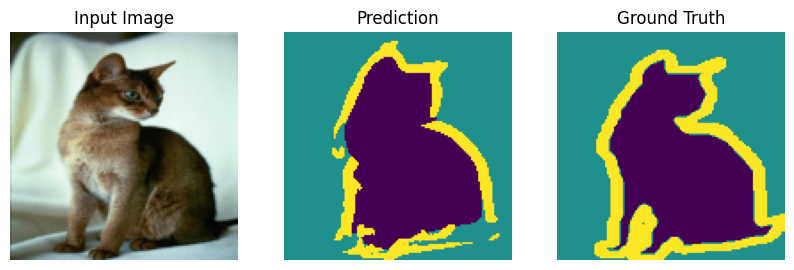

Epochs: 2/30
train loss: 0.4608722233253977
test loss: 0.4800229178822559
Test image_80 after epoch 2: 


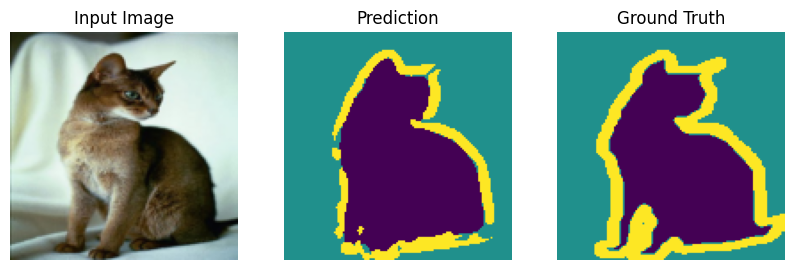

Epochs: 3/30
train loss: 0.41954148619071296
test loss: 0.39465022916379183
Test image_80 after epoch 3: 


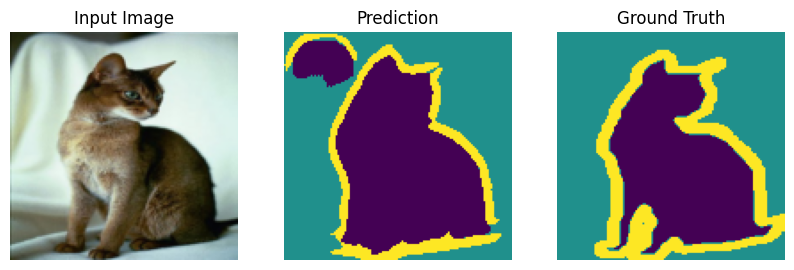

Epochs: 4/30
train loss: 0.3794462937375774
test loss: 0.3811134817807571
Test image_80 after epoch 4: 


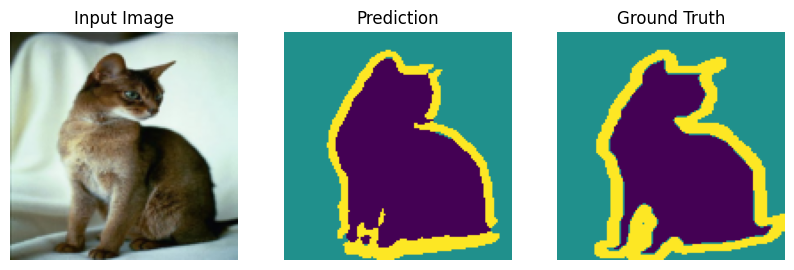

Epochs: 5/30
train loss: 0.36539423180663066


In [ ]:
test_index = 80
display_image = test_set[test_index][0]
display_target = test_set[test_index][1]

for epoch in range(epochs):
  train_loss = 0.0
  model.train()
  for image, label in train_loader:
    image = image.to(device)
    label = label.to(device)

    optimizer.zero_grad()
    logit = model(image)
    loss = criterion(logit, label)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
  train_loss /= len(train_loader)

  print(f"Epochs: {epoch + 1}/{epochs}")
  print(f"train loss: {train_loss}")
  print(f"test loss: {evaluate(test_loader, model)}")
  print(f"Test image_{test_index} after epoch {epoch+1}: ")
  display_prediction(model, display_image, display_target)

In [ ]:
# Save model...